<a href="https://colab.research.google.com/github/sidraibrar69-create/news-topic-classifier/blob/main/bert_news_topic_classifier_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install Required Libraries

In [5]:
!pip -q install transformers datasets accelerate gradio scikit-learn seaborn

In [6]:
!pip install --upgrade datasets huggingface_hub

## 2. Import Libraries and Set Configuration

In [7]:
import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline,
)

import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = 'bert-base-uncased'
OUTPUT_DIR = '/content/bert_ag_news_classifier'

# Keep FAST_RUN=True if you want the notebook to finish quickly in Colab.
# Set FAST_RUN=False to train on the full AG News dataset.
FAST_RUN = True
MAX_TRAIN_SAMPLES = 8000
MAX_TEST_SAMPLES = 2000

MAX_LENGTH = 128
NUM_EPOCHS = 2
BATCH_SIZE = 16

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


## 3. Load AG News Dataset

The AG News dataset contains news text and topic labels. In Hugging Face Datasets, the text column is named `text` and the label column is named `label`.

In [9]:
dataset = load_dataset("fancyzhx/ag_news")

label_names = dataset['train'].features['label'].names
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in id2label.items()}

print(dataset)
print('Labels:', id2label)

sample_df = pd.DataFrame(dataset['train'][:5])
sample_df['topic'] = sample_df['label'].map(id2label)
sample_df

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Labels: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


,text,label,topic
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


## 4. Optional Subsampling for Faster Colab Training

In [10]:
if FAST_RUN:
    train_dataset = dataset['train'].shuffle(seed=SEED).select(range(MAX_TRAIN_SAMPLES))
    test_dataset = dataset['test'].shuffle(seed=SEED).select(range(MAX_TEST_SAMPLES))
else:
    train_dataset = dataset['train'].shuffle(seed=SEED)
    test_dataset = dataset['test'].shuffle(seed=SEED)

# Split part of training data into validation data.
split_dataset = train_dataset.train_test_split(test_size=0.15, seed=SEED)
train_dataset = split_dataset['train']
val_dataset = split_dataset['test']

print('Train samples:', len(train_dataset))
print('Validation samples:', len(val_dataset))
print('Test samples:', len(test_dataset))

Train samples: 6800
Validation samples: 1200
Test samples: 2000


## 5. Tokenize and Preprocess the Dataset

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_tokenized = train_dataset.map(tokenize_batch, batched=True)
val_tokenized = val_dataset.map(tokenize_batch, batched=True)
test_tokenized = test_dataset.map(tokenize_batch, batched=True)

columns_to_remove = ['text']
train_tokenized = train_tokenized.remove_columns(columns_to_remove)
val_tokenized = val_tokenized.remove_columns(columns_to_remove)
test_tokenized = test_tokenized.remove_columns(columns_to_remove)

train_tokenized = train_tokenized.rename_column('label', 'labels')
val_tokenized = val_tokenized.rename_column('label', 'labels')
test_tokenized = test_tokenized.rename_column('label', 'labels')

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_tokenized[0]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/6800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'labels': 2,
 'input_ids': [101,
  7842,
  5705,
  2000,
  2485,
  2340,
  5324,
  1010,
  6352,
  5841,
  3013,
  2047,
  2259,
  1006,
  26665,
  1007,
  1011,
  20196,
  7842,
  5705,
  4297,
  1012,
  1004,
  8318,
  1025,
  1037,
  17850,
  12879,
  1027,
  1000,
  8299,
  1024,
  1013,
  1013,
  7479,
  1012,
  14316,
  1012,
  26665,
  1012,
  4012,
  1013,
  2440,
  28940,
  12184,
  1012,
  2004,
  2361,
  2595,
  1029,
  16356,
  2121,
  1027,
  15315,
  2015,
  1012,
  1050,
  4539,
  1027,
  1013,
  15768,
  1013,
  4248,
  2378,
  14876,
  1013,
  2440,
  28940,
  12184,
  1000,
  1004,
  14181,
  1025,
  15315,
  2015,
  1012,
  1050,
  1004,
  8318,
  1025,
  1013,
  1037,
  1004,
  14181,
  1025,
  2006,
  5958,
  2056,
  2009,
  2097,
  2485,
  2809,
  1997,
  2049,
  9542,
  7842,
  5705,
  3587,
  3927,
  5324,
  1998,
  2093,
  1997,
  2049,
  2896,
  1011,
  3976,
  2125,
  4833,
  5324,
  1010,
  4525,
  1999,
  1037,
  3279,
  1997,
  6352,
  5841,
  2012,
  221

## 6. Load BERT Model for Text Classification

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

model.to(device)
print('Loaded model:', MODEL_NAME)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded model: bert-base-uncased


## 7. Define Evaluation Metrics

In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average='macro')
    weighted_f1 = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
    }

## 8. Fine-Tune BERT

In [15]:
import inspect

training_kwargs = {
    'output_dir': OUTPUT_DIR,
    'learning_rate': 2e-5,
    'per_device_train_batch_size': BATCH_SIZE,
    'per_device_eval_batch_size': BATCH_SIZE,
    'num_train_epochs': NUM_EPOCHS,
    'weight_decay': 0.01,
    'save_strategy': 'epoch',
    'logging_strategy': 'steps',
    'logging_steps': 50,
    'load_best_model_at_end': True,
    'metric_for_best_model': 'macro_f1',
    'greater_is_better': True,
    'report_to': 'none',
    'seed': SEED,
}

# Hugging Face versions differ slightly on this argument name.
if 'eval_strategy' in inspect.signature(TrainingArguments).parameters:
    training_kwargs['eval_strategy'] = 'epoch'
else:
    training_kwargs['evaluation_strategy'] = 'epoch'

training_args = TrainingArguments(**training_kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    # tokenizer=tokenizer, # Removed this line as it's no longer accepted
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.263145,0.327973,0.898333,0.897447,0.897993
2,0.184643,0.329281,0.915000,0.914453,0.914905


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=850, training_loss=0.2957321503583123, metrics={'train_runtime': 274.4077, 'train_samples_per_second': 49.561, 'train_steps_per_second': 3.098, 'total_flos': 639486458787072.0, 'train_loss': 0.2957321503583123, 'epoch': 2.0})

## 9. Evaluate on the Test Set

In [16]:
test_metrics = trainer.evaluate(test_tokenized)
test_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.184643,0.297049,2,0.913500,0.914538,0.913571


{'eval_loss': 0.2970488965511322,
 'eval_accuracy': 0.9135,
 'eval_macro_f1': 0.9145376050585968,
 'eval_weighted_f1': 0.9135707147966042}

In [17]:
test_predictions = trainer.predict(test_tokenized)
predicted_labels = np.argmax(test_predictions.predictions, axis=-1)
true_labels = test_predictions.label_ids

print('Accuracy:', accuracy_score(true_labels, predicted_labels))
print('Macro F1:', f1_score(true_labels, predicted_labels, average='macro'))
print('Weighted F1:', f1_score(true_labels, predicted_labels, average='weighted'))
print('\nClassification Report:\n')
print(classification_report(true_labels, predicted_labels, target_names=label_names))

Accuracy: 0.9135
Macro F1: 0.9145376050585968
Weighted F1: 0.9135707147966042

Classification Report:

              precision    recall  f1-score   support

       World       0.95      0.90      0.92       497
      Sports       0.97      0.98      0.98       483
    Business       0.89      0.85      0.87       522
    Sci/Tech       0.85      0.92      0.88       498

    accuracy                           0.91      2000
   macro avg       0.92      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



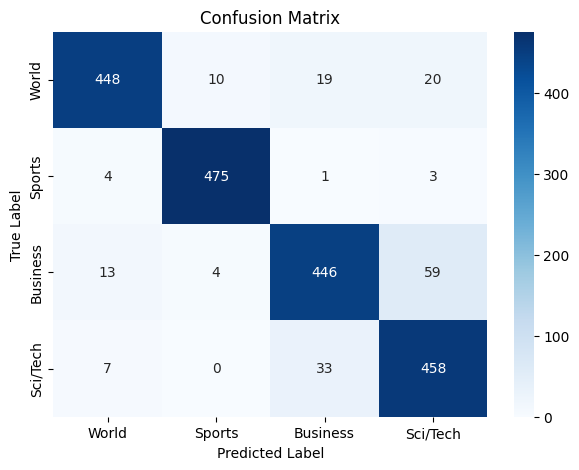

In [18]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 10. Save the Fine-Tuned Model

In [19]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print('Model saved to:', OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/bert_ag_news_classifier


## 11. Test Single Predictions

In [21]:
classifier = pipeline(
    'text-classification',
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=True,
)

examples = [
    'Global leaders meet to discuss a new peace agreement.',
    'The team scored twice in the final minutes to win the championship.',
    'Stocks rose after the company reported record quarterly profits.',
    'A new AI chip promises faster performance for mobile devices.',
]

for text in examples:
    scores = classifier(text)[0]
    # The 'scores' variable (after classifier(text)[0]) is already a dictionary
    # containing the best prediction's label and score, e.g., {'label': 'World', 'score': 0.9944}.
    # Therefore, we can use it directly instead of applying max() to it.
    best = scores
    print('Text:', text)
    print('Prediction:', best['label'], '| Confidence:', round(best['score'], 4))
    print('-' * 80)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Text: Global leaders meet to discuss a new peace agreement.
Prediction: World | Confidence: 0.9944
--------------------------------------------------------------------------------
Text: The team scored twice in the final minutes to win the championship.
Prediction: Sports | Confidence: 0.9907
--------------------------------------------------------------------------------
Text: Stocks rose after the company reported record quarterly profits.
Prediction: Business | Confidence: 0.99
--------------------------------------------------------------------------------
Text: A new AI chip promises faster performance for mobile devices.
Prediction: Sci/Tech | Confidence: 0.9867
--------------------------------------------------------------------------------


## 12. Deploy with Gradio

Run this cell to open a live web interface inside Colab. Type a news headline or short news text and the model will return the predicted topic with confidence scores.

In [22]:
def classify_news(text):
    if not text or not text.strip():
        return {'Please enter a news headline or article text.': 0.0}

    scores = classifier(text)[0]
    return {item['label']: float(item['score']) for item in scores}


demo = gr.Interface(
    fn=classify_news,
    inputs=gr.Textbox(
        lines=5,
        placeholder='Enter a news headline, for example: Tech companies unveil new AI tools at global conference',
        label='News Text',
    ),
    outputs=gr.Label(num_top_classes=4, label='Predicted Topic'),
    title='BERT News Topic Classifier',
    description='Fine-tuned BERT model for AG News topic classification.',
    examples=[
        ['Government officials announced new international trade policies today.'],
        ['The football club signed a star striker before the new season.'],
        ['The stock market closed higher after strong earnings reports.'],
        ['Scientists developed a faster processor for next generation computers.'],
    ],
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dd8650d0fa93b81660.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
